In [20]:
# Peptide areas of all peptides assigned to a protein (histone), normalised on all proteins in the sample, averaged between 2 replicates
# Log2FC (fold change of peptide areas) vs Basiline (average abundance)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib as mpl
from adjustText import adjust_text
from matplotlib.ticker import FuncFormatter, FixedLocator


In [2]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # TrueType
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.size'] = 16 


In [3]:
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter, FixedLocator

In [ ]:
# import the resulting excel table
Histone_mass_spec = pd.read_excel('histones_mass_spec/Khauratovich_Goloborodko_IMBA_ID2045_20250423_E4_insol_Urea_ArgC_2x2runs_mouse_histones_Top100_quanOnAll_v2.xlsm', sheet_name="Main", skiprows=2)


In [5]:
Histone_mass_spec = Histone_mass_spec[['Histones', 'Genes [v1]', 'Quantified Peptides', '20250423_E4_NEO8_Khauratovich_Goloborodko_IMBA_ID2045_insol_dig_Urea_DTT_ArgC_20per_control_rep1', '20250423_E4_NEO8_Khauratovich_Goloborodko_IMBA_ID2045_insol_dig_Urea_DTT_ArgC_20per_control_rep2', '20250423_E4_NEO8_Khauratovich_Goloborodko_IMBA_ID2045_insol_dig_Urea_DTT_ArgC_20per_sample_Chd1KO_rep1', '20250423_E4_NEO8_Khauratovich_Goloborodko_IMBA_ID2045_insol_dig_Urea_DTT_ArgC_20per_sample_Chd1KO_rep2', 'SumPSMs', 'log2(Fold change (imputed))']]
Histone_mass_spec = Histone_mass_spec.iloc[2:].reset_index(drop=True)

In [6]:
Histone_mass_spec.columns = ['Histone_tick', 'Gene', 'Peptides', 'Ctr_1_area_norm', 'Ctr_2_area_norm', 'CHD1KO_1_area_norm', 'CHD1KO_2_area_norm', 'SumPSMs', 'Log2_FC']

Histone_mass_spec_f = Histone_mass_spec[Histone_mass_spec['Peptides'] > 2].copy()

Histone_mass_spec_f = Histone_mass_spec_f.astype({
    'Histone_tick': 'string',
    'Gene': 'string',
    'Peptides': 'float',
    'Ctr_1_area_norm': 'float',
    'Ctr_2_area_norm': 'float',
    'CHD1KO_1_area_norm': 'float',
    'CHD1KO_2_area_norm': 'float',
    'SumPSMs': 'float',
    'Log2_FC': 'float'
})

Histone_mass_spec_f['Histone_tick'] = (
    Histone_mass_spec_f['Histone_tick']
    .replace('ü', 'histone')
    .fillna('0')
)

Histone_mass_spec_f['Baseline'] = (
    Histone_mass_spec_f[['Ctr_1_area_norm', 'Ctr_2_area_norm', 'CHD1KO_1_area_norm', 'CHD1KO_2_area_norm']].mean(axis=1)
)

In [7]:
Histone_mass_spec_f

,Histone_tick,Gene,Peptides,Ctr_1_area_norm,Ctr_2_area_norm,CHD1KO_1_area_norm,CHD1KO_2_area_norm,SumPSMs,Log2_FC,Baseline
0,0,Tnp2,15.0,2.179301e+09,1.676163e+09,8.301325e+08,6.474760e+08,209.0,-1.382358,1.333268e+09
1,0,Psip1,34.0,1.556768e+09,1.502233e+09,1.564048e+09,1.626955e+09,679.0,0.060899,1.562501e+09
2,0,Ybx2,25.0,1.445913e+09,1.281710e+09,1.157345e+09,8.866847e+08,278.0,-0.426369,1.192913e+09
3,0,Cox6c,13.0,1.001894e+09,6.624878e+08,1.354730e+09,1.290149e+09,131.0,0.698423,1.077315e+09
4,0,Alyref,32.0,1.080822e+09,9.556467e+08,1.023039e+09,1.043652e+09,250.0,0.023912,1.025790e+09
...,...,...,...,...,...,...,...,...,...,...
121,histone,H2al1k,4.0,1.611597e+07,1.191952e+07,7.405779e+06,7.169098e+06,14.0,-0.927615,1.065259e+07
122,0,Prrc2a,20.0,7.206105e+06,8.493410e+06,5.702357e+06,4.246984e+06,66.0,-0.668783,6.412214e+06
123,0,Hdgfl2,15.0,8.112477e+06,8.283890e+06,6.734431e+06,8.196049e+06,36.0,-0.141983,7.831712e+06
124,0,HRNR,14.0,2.603643e+06,1.146947e+06,1.121823e+06,1.160596e+06,62.0,-0.598810,1.508253e+06


In [8]:
Histone_mass_spec_f['Names'] = Histone_mass_spec_f['Gene'].copy()

custom_gene_names = {
    "H4c1; H4c11; H4c12; H4c14; H4c16; H4c2; H4c3; H4c4; H4c6; H4c8; H4c9; Hist1h4m": "H4",
    "H3-3a; H3-3b": "H3-3",
    "H3f4": "H3t",
    "H1-6": "H1t",
    "H1-7": "H1T2",
    "H1-9": "H1FOO",
    "H1f10": "H1-10",
    "H2bu2": "TH2B"
}

Histone_mass_spec_f['Names'] = Histone_mass_spec_f['Names'].replace(custom_gene_names)

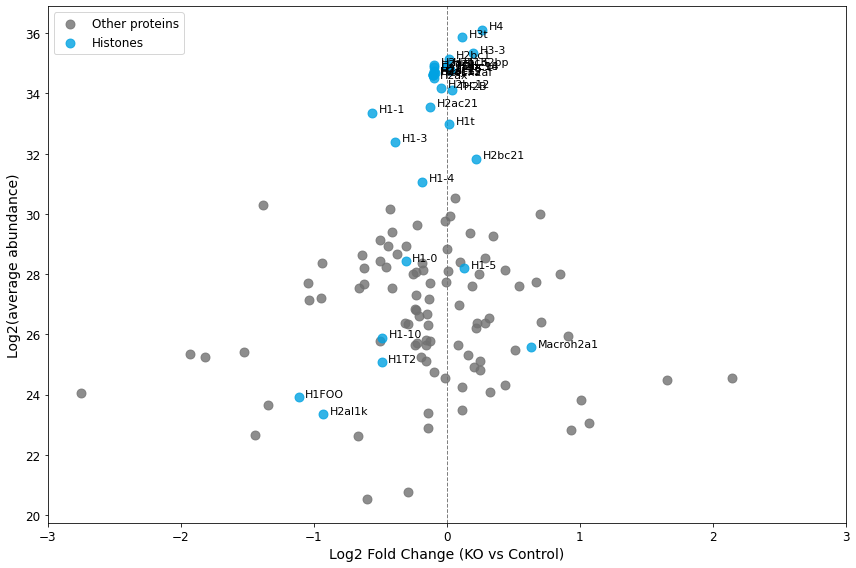

In [ ]:
import matplotlib.pyplot as plt

# Separate histones and non-histones
histones = Histone_mass_spec_f[Histone_mass_spec_f['Histone_tick'] == 'histone']
non_histones = Histone_mass_spec_f[Histone_mass_spec_f['Histone_tick'] != 'histone']

plt.figure(figsize=(12, 8))

# Plot non-histones
plt.scatter(
    non_histones['Log2_FC'],
    np.log2(non_histones['Baseline']),
    color='#717171', #grey
    s=80,
    alpha=0.8,
    label='Other proteins'
)

# Highlight histones
plt.scatter(
    histones['Log2_FC'],
    np.log2(histones['Baseline']),
    color='#00a2e2', #blue
    s=80,
    alpha=0.8,
    label='Histones'
)

# x = 0
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1, zorder=0)

plt.xlim(-3, 3)

plt.xlabel('Log2 Fold Change (KO vs Control)', fontsize=14)
plt.ylabel('Log2(average abundance)', fontsize=14)

# Ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Label only histones
for _, row in histones.iterrows():
    plt.text(
        row['Log2_FC'] + 0.05,        # x-offset
        np.log2(row['Baseline']) + 0.01,  # y-offset
        str(row['Names']),
        fontsize=11,
        color='black'
    )

plt.legend(fontsize=12, loc='upper left')

plt.tight_layout()
plt.show()

# plt.savefig(
#     "Histones_mass_spec_basemean_allProtsNorm_logScale_labels.pdf",
#     format='pdf',
#     dpi=600,
#     bbox_inches="tight",
#     pad_inches=1,
#     transparent=False
# )

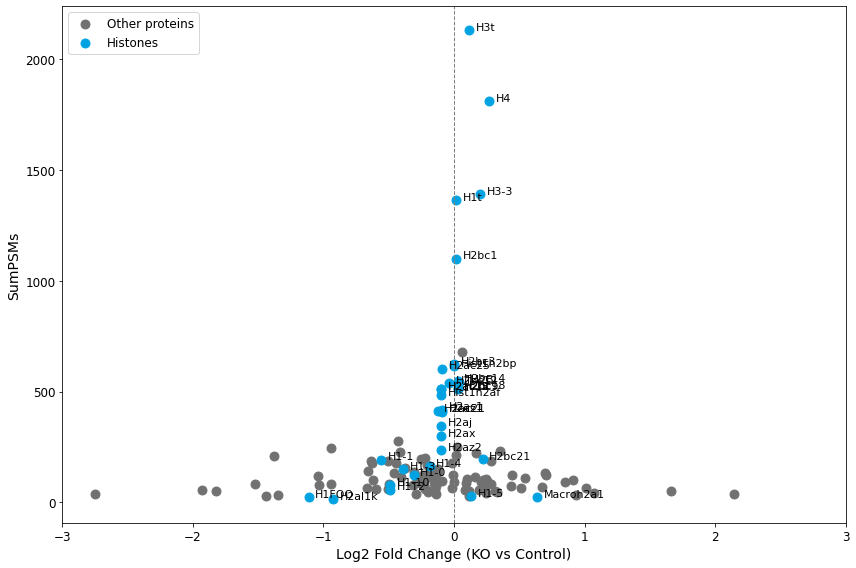

In [10]:
import matplotlib.pyplot as plt

# Separate histones and non-histones
histones = Histone_mass_spec_f[Histone_mass_spec_f['Histone_tick'] == 'histone']
non_histones = Histone_mass_spec_f[Histone_mass_spec_f['Histone_tick'] != 'histone']

# Set figure size and style
plt.figure(figsize=(12, 8))

# Plot non-histones in gray (bottom layer)
plt.scatter(
    non_histones['Log2_FC'],
    non_histones['SumPSMs'],
    color='#717171',
    s=80,
    label='Other proteins'
)

# Plot histones in blue (top layer)
plt.scatter(
    histones['Log2_FC'],
    histones['SumPSMs'],
    color='#00a2e2',
    s=80,
    label='Histones'
)

# Add vertical line at x = 0
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)

# Axis limits
plt.xlim(-3, 3)

# Labels and title
plt.xlabel('Log2 Fold Change (KO vs Control)', fontsize=14)
plt.ylabel('SumPSMs', fontsize=14)

# Ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Label only histones
for _, row in histones.iterrows():
    plt.text(
        row['Log2_FC'] + 0.05,        # x-offset
        row['SumPSMs'] + 0.01,  # y-offset
        str(row['Names']),
        fontsize=11,
        color='black'
    )

# Legend
plt.legend(fontsize=12, loc='upper left')

# Layout
plt.tight_layout()
plt.show()